## Load libraries

In [27]:
from IPython.display  import display
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## Exercise 1: 

### Read and display image

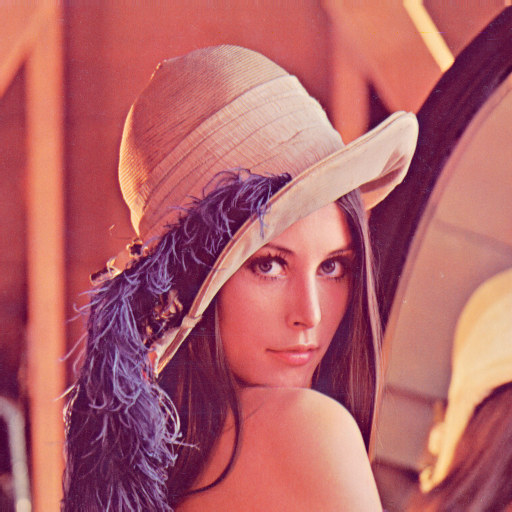

In [28]:
# read and display image
image = Image.open("./assets/input.png")
display(image)

### Display top left corner of 100x100

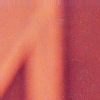

In [29]:
left = 0
upper = 0
right = left + 100
lower = left + 100

top_left = image.crop((left, upper, right, lower))
top_left

### Show three color channels

In [30]:
image_array = np.array(image)
image_array.shape
red = image_array[:, :, 0]
print(red)
green = image_array[:, :, 1]
print(green)
blue = image_array[:, :, 2]
print(blue)

[[226 226 223 ... 230 221 200]
 [226 226 223 ... 230 221 200]
 [226 226 223 ... 230 221 200]
 ...
 [ 84  84  92 ... 173 172 177]
 [ 82  82  96 ... 179 181 185]
 [ 82  82  96 ... 179 181 185]]
[[137 137 137 ... 148 130  99]
 [137 137 137 ... 148 130  99]
 [137 137 137 ... 148 130  99]
 ...
 [ 18  18  27 ...  73  68  62]
 [ 22  22  32 ...  70  71  74]
 [ 22  22  32 ...  70  71  74]]
[[125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 ...
 [ 60  60  58 ...  84  76  79]
 [ 57  57  62 ...  79  81  81]
 [ 57  57  62 ...  79  81  81]]


### Modify top pixels

In [31]:
modified = image_array.copy() 
modified[:100, :100,: ] = 210
modified_top = Image.fromarray(modified)

### Display all results

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

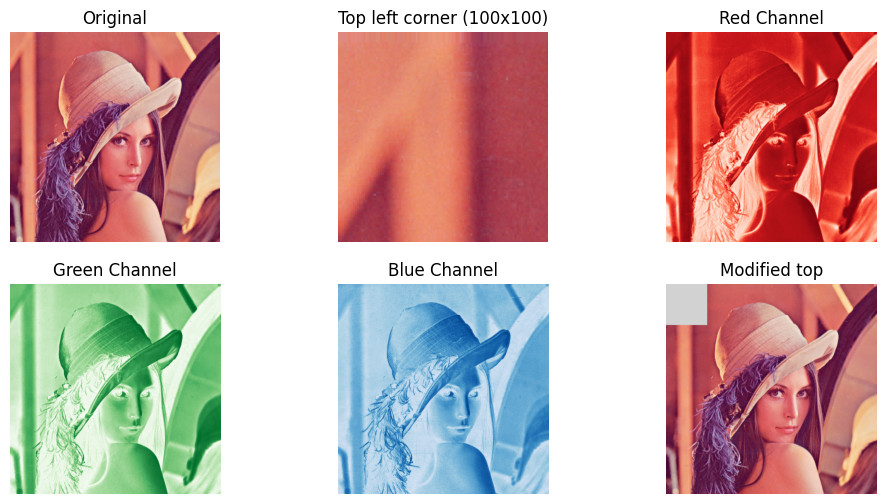

In [32]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(top_left)
plt.title("Top left corner (100x100)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(red, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(green, cmap="Greens")
plt.title("Green Channel")

plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(blue, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(modified_top)
plt.title("Modified top")
plt.axis("off")

## Exercise 2:

### Load and display grayscale image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

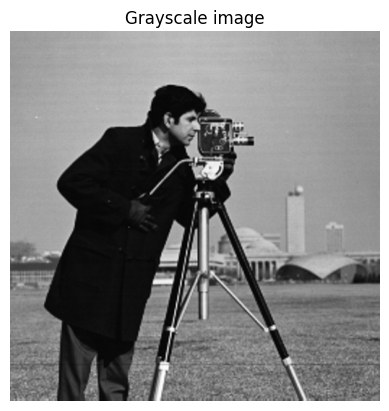

In [33]:
image_grayed = Image.open("./assets/cameraman.png").convert("L")
plt.imshow(image_grayed, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")

### Middle section of the image (150 pixels)

Center 256 256


(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

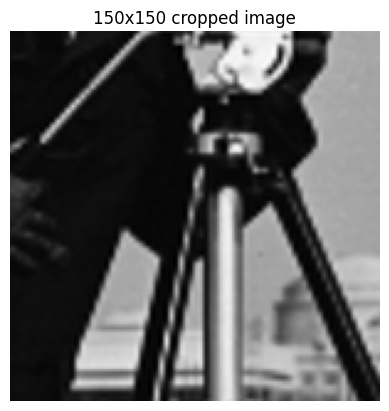

In [34]:
image_arr_grayed = np.array(image_grayed)
height, width = image_arr_grayed.shape
center_x = height // 2
center_y = width // 2
print(f"Center {center_x} {center_y}")

crop_size = 150

start_x = center_x - crop_size // 2
end_x = center_x + crop_size // 2
start_y = center_y - crop_size // 2
end_y = center_y + crop_size // 2

cropped = image_arr_grayed[start_x:end_x, start_y:end_y]

plt.imshow(cropped, cmap="gray")
plt.title("150x150 cropped image")
plt.axis("off")

### Threshold to image

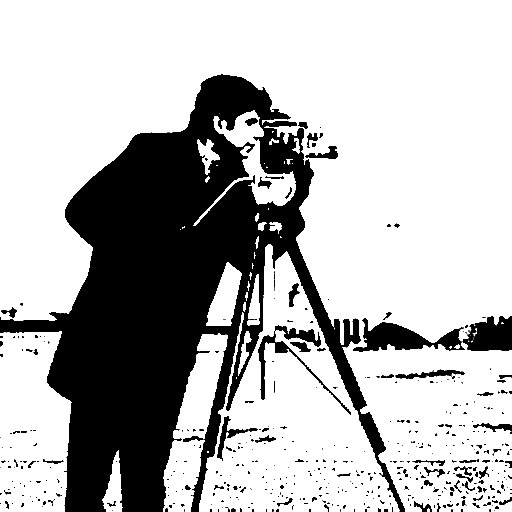

In [35]:
image_arr_grayed[image_arr_grayed < 100] = 0
image_arr_grayed[image_arr_grayed > 100] = 255
display(Image.fromarray(image_arr_grayed))

### Rotating Image by 90 degress

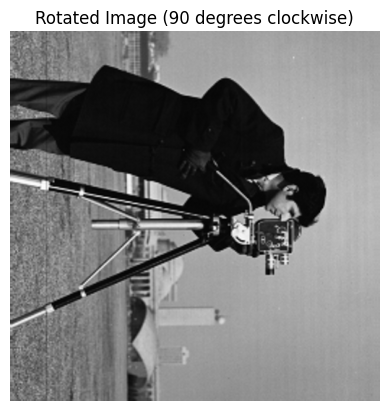

In [36]:
rotated = image_grayed.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image (90 degrees clockwise)")
plt.axis('off')
plt.show()

### Converting to RGB

Bands ('R', 'G', 'B')


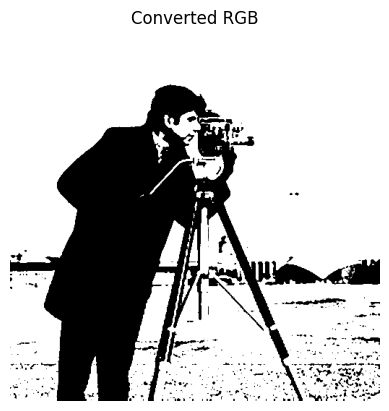

In [37]:
rgb_image = np.stack((image_arr_grayed, image_arr_grayed, image_arr_grayed),axis=2)
print(f"Bands {Image.fromarray(rgb_image).getbands()}")

plt.imshow(rgb_image)
plt.title("Converted RGB")
plt.axis('off')
plt.show()

## Exercise 3: Image Compression Decompression (PCA)

### Load and prepare data

In [38]:
# Fetch and convert to grayscale
new_image = Image.open("./assets/input.png").convert("L")
new_image.getbands()

('L',)

In [39]:
# center / standardize the dataset
data = np.array(new_image)
mean = np.mean(data, axis=0)
centered_data = data - mean

In [40]:
# the covariance matix
cov_matrix = np.cov(centered_data, rowvar=False)

### Eigen Decomposition and Principal Components

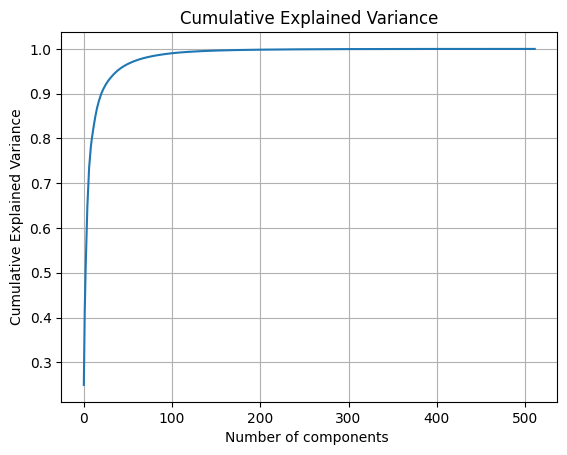

In [41]:
# Compute eigen values and vectors

eigenvalues, eigenvector = np.linalg.eigh(cov_matrix)

# Sorting in descending order 
sorted_indices = np.argsort(eigenvalues)[::-1] # get the indices
eigenvalues = eigenvalues[sorted_indices]; # sort the values
eigenvector = eigenvector[:, sorted_indices] # sort the vectors {col}

# Now they are principal Components
# but how much to choose ? lets decide by graph of explained variance

explained_variance_ratio = eigenvalues/ sum(eigenvalues)
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of components ")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

### Picking the top k components

In [42]:
# Wrapping the functionality in function ? 
def pick_k(X: np.ndarray, eigenvector: np.ndarray, k: int):
    """Picks the passed k number of principal components and returns compressed and decompressed image

    Parameters
    ----------
    X : np.ndarray
        standardized Image array 
    eigenvector : np.ndarray
        Eigen vectors to compress from
    k : int
        Value of principal components to pick

    Returns
    -------
    tuple[np.ndarray, np.ndarray ]
        Tuple of compressed and decompressed images

    """
    try:
        components = eigenvector[:, :k]

        # get the compressed image
        compressed = np.dot(X, components)

        # Decompress the data
        decompressed = np.dot(compressed, components.T)

        return (compressed, decompressed)
    except Exception as e: 
        print("Exception occured. Check the shape.", e)
        raise

## Reconstruction and Experiment

### picking different value of k

In [43]:
top_10_comp, top_10_decomp = pick_k(centered_data, eigenvector, 10)
top_20_comp, top_20_decomp = pick_k(centered_data, eigenvector, 20)
top_50_comp, top_50_decomp = pick_k(centered_data, eigenvector, 50)
top_100_comp, top_100_decomp = pick_k(centered_data, eigenvector, 100)
top_150_comp, top_150_decomp = pick_k(centered_data, eigenvector, 150)

### Visualization  of top 150 

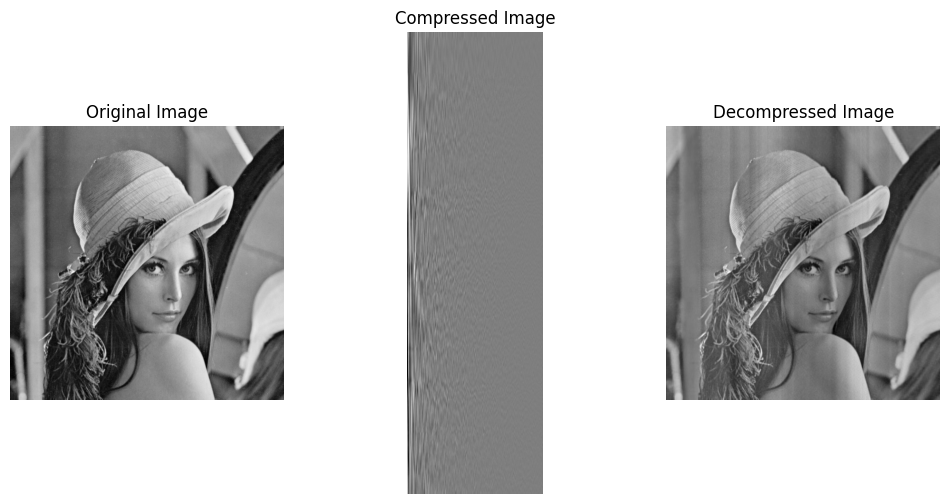

In [44]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(new_image, cmap="gray")
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(top_150_comp, cmap="gray")
plt.title("Compressed Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(top_150_decomp, cmap="gray")
plt.title("Decompressed Image")
plt.axis('off')
plt.show()

### Visualization  different experiments

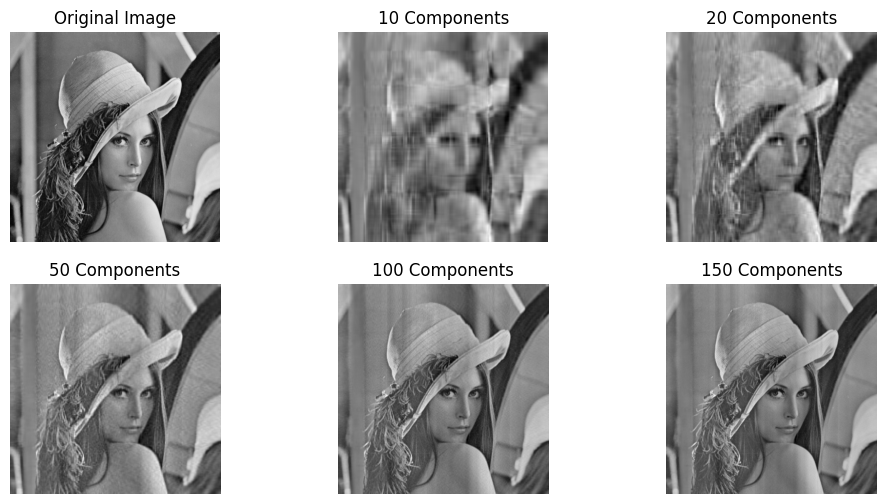

In [45]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(new_image, cmap="gray")
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(top_10_decomp, cmap="gray")
plt.title("10 Components")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(top_20_decomp, cmap="gray")
plt.title("20 Components")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(top_50_decomp, cmap="gray")
plt.title("50 Components")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(top_100_decomp, cmap="gray")
plt.title("100 Components")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(top_150_decomp, cmap="gray")
plt.title("150 Components")
plt.axis('off')
plt.show()